In [1]:
from IPython.display import HTML
HTML('''
    <style> body {font-family: "Roboto Condensed Light", "Roboto Condensed";} h2 {padding: 10px 12px; background-color: #E64626; position: static; color: #ffffff; font-size: 40px;} .text_cell_render p { font-size: 15px; } .text_cell_render h1 { font-size: 30px; } h1 {padding: 10px 12px; background-color: #E64626; color: #ffffff; font-size: 40px;} .text_cell_render h3 { padding: 10px 12px; background-color: #0148A4; position: static; color: #ffffff; font-size: 20px;} h4:before{ 
    content: "@"; font-family:"Wingdings"; font-style:regular; margin-right: 4px;} .text_cell_render h4 {padding: 8px; font-family: "Roboto Condensed Light"; position: static; font-style: italic; background-color: #FFB800; color: #ffffff; font-size: 18px; text-align: center; border-radius: 5px;}input[type=submit] {background-color: #E64626; border: solid; border-color: #734036; color: white; padding: 8px 16px; text-decoration: none; margin: 4px 2px; cursor: pointer; border-radius: 20px;}</style>
''')

# Machine Learning

Utilising a Supervised Linear Regression, we will attempt to predict the number of 'Exams_Sat' using other parts of our data.

First need to import that relevant libraries for our Linear Regression.

In [82]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
from sklearn import linear_model
from sklearn import metrics
from sklearn.model_selection import train_test_split

Next we need to load our data into a Dataframe to prepare it. This includes separating our variables.

In [83]:
data = pd.read_csv("Task 3 Combined Data.csv")
input_columns = ['num_0_19_people','young_perc','num_schools','median_income','total_turnover'] #This includes only the Columns we are using to guess 'Exams_Sat'

We plan on using a Linear regression, which demands all null values are dealt with. Since we intend to use this model to predict for null values, for the best result, we will drop all null values. Unfortunately this leaves us with only 117 data points remaining, which may result in a poor model.

In [85]:
required_columns = input_columns.copy()
required_columns.append('exams_sat')  #This includes all the Input columns + Target Variable Column.
data_clean = data[required_columns].copy() #Copy used so we don't alter the original data too much, in case we need to access it later.
data_clean.dropna(inplace=True)
print('Number of Data Points:',len(data_clean))


Number of Data Points: 117


Finally we can create our Model, separating the target variable from the rest, and splitting the data into Training and Testing.

In [86]:
X = data_clean[input_columns]
Y = data_clean['exams_sat']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.1, random_state = 45)
regression_model = linear_model.LinearRegression().fit(X_train, Y_train)

Once the model is initialised we can proceed to use different Metrics to gauge its effectiveness.

In [87]:
Y_predictions = regression_model.predict(X_test) #Create a list of our predicted values
mse_metric = metrics.root_mean_squared_error(Y_test, Y_predictions)
r2_metric = metrics.r2_score(Y_test,Y_predictions)
max_error = metrics.max_error(Y_test,Y_predictions)
print('Root Mean Square Error:',mse_metric,'\nR-Squared:', r2_metric,'\nMaximum Error:', max_error)

Root Mean Square Error: 511.0853936570068 
R-Squared: 0.3155561511601589 
Maximum Error: 846.0546802228378


In addition to the numerical results we can plot our predictions against the true values, to better visualise all of our models predictions. To show the distribution of offsets we have also plotted the sorted distances between the real values and predictions.

Wwe can see how often we over-estimate compared to under-estimate; but more importantly, how often we accurately guess close to the real value. Looking at the results we can see our Model is far more prone to overestimating the number of exams sat, rather than underestimating.

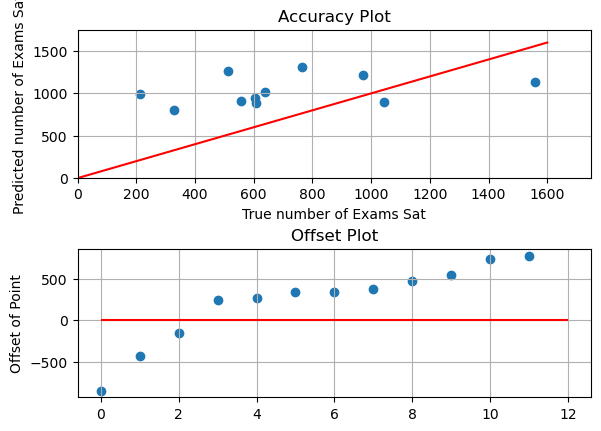

In [115]:
offsets =list(Y_predictions - Y_test)
offsets.sort()

fig, axs = plt.subplots(2)
fig.tight_layout(pad=3)
# Plot Predictions against True Values
axs[0].scatter(Y_test,Y_predictions)
axs[0].set_title('Accuracy Plot')
axs[0].set_xlabel('True number of Exams Sat')
axs[0].set_ylabel('Predicted number of Exams Sat')
axs[0].set_xlim(0,1750)
axs[0].set_ylim(0,1750)
axs[0].grid()
axs[0].plot([0,1600],[0,1600],color='red') # Line to show ideal result

#Plot Ordered offset of predictions
axs[1].scatter(range(len(offsets)),offsets)
axs[1].set_title('Offset Plot')
axs[1].set_label('Ordered Datapoints')
axs[1].set_ylabel('Offset of Point')
axs[1].grid()
axs[1].hlines(0,xmin=0,xmax=12,color='red') # Line to show ideal result

One possible issue is in our original assumption of correlation between 'exams sat' and the other variables we have access to. Plotting a Correlation matrix we can see that this is indeed correct, and the actual level of correlation is insubstantial.

<Axes: >

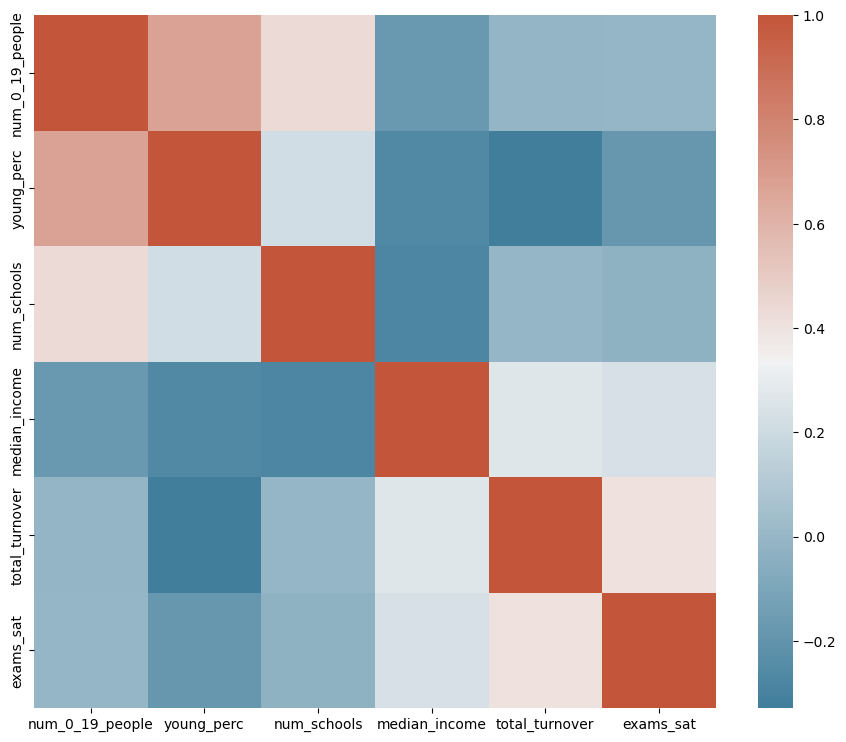

In [81]:
numeric_columns = list(data.columns)[9:]
corr = data_clean.corr()
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, sep=1, center='light', as_cmap=True)
sns.heatmap(corr,cmap=cmap)